In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

In [6]:
df = pd.read_csv(r'/content/WA_Fn-UseC_-Telco-Customer-Churn.csv')
df.head(-10)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7028,9281-CEDRU,Female,0,Yes,No,68,Yes,No,DSL,No,...,No,Yes,Yes,No,Two year,No,Bank transfer (automatic),64.10,4326.25,No
7029,2235-DWLJU,Female,1,No,No,6,No,No phone service,DSL,No,...,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,44.40,263.05,No
7030,0871-OPBXW,Female,0,No,No,2,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Month-to-month,Yes,Mailed check,20.05,39.25,No
7031,3605-JISKB,Male,1,Yes,No,55,Yes,Yes,DSL,Yes,...,No,No,No,No,One year,No,Credit card (automatic),60.00,3316.1,No


In [5]:
df.sample(n = 5)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
2258,9150-HEPMB,Male,0,No,No,56,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,52.70,3019.7,No
759,5684-FJVYR,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,Yes,...,No,Yes,No,No,Two year,Yes,Bank transfer (automatic),90.35,6563.4,No
4331,5743-KHMNA,Male,0,No,No,71,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Bank transfer (automatic),25.55,1898.1,No
4624,0325-XBFAC,Male,0,No,No,8,Yes,No,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,94.70,740.3,Yes
4196,6963-KQYQB,Female,0,Yes,Yes,70,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,24.05,1764.75,No


In [7]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [10]:
df.shape

(7043, 21)

In [11]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [13]:
df.drop('customerID',axis = 1, inplace=True) #customerID is useless for us here

In [15]:
df['gender'].value_counts()

,count
gender,
Male,3555
Female,3488


([<matplotlib.patches.Wedge at 0x7f89c38fda60>,
 [Text(-0.016436740380449354, 1.099877190219738, 'Male'),
  Text(0.016436836534770922, -1.0998771887827883, 'Female')],
 [Text(-0.008965494752972375, 0.5999330128471297, '50.5%'),
  Text(0.008965547200784138, -0.599933012063339, '49.5%')])

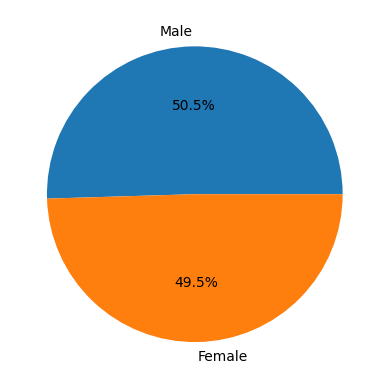

In [20]:
import seaborn as sns
plt.pie(df['gender'].value_counts(),labels = ['Male','Female'],autopct='%.1f%%')

In [21]:
df['gender']=df['gender'].map({'Male':0,'Female':1})

In [23]:
df['Partner'].value_counts()

,count
Partner,
No,3641
Yes,3402


Text(0, 0.5, 'count')

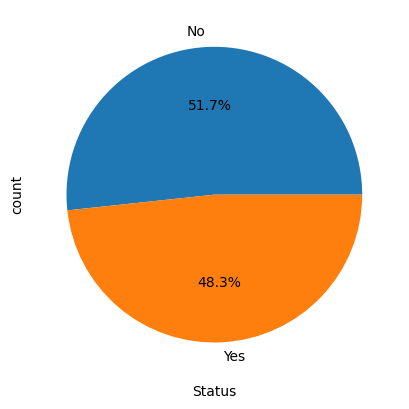

In [25]:
plt.pie(df['Partner'].value_counts(),labels = ['No','Yes'],autopct='%.1f%%')
plt.xlabel('Status')
plt.ylabel('count')

In [26]:
df['Partner'] = df['Partner'].map({'No': 0, 'Yes': 1})

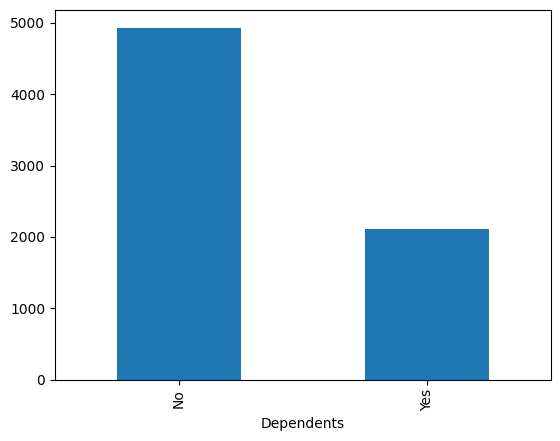

In [29]:
df['Dependents'].value_counts().plot(kind='bar')
df['Dependents'] = df['Dependents'].map({'No': 0, 'Yes': 1})

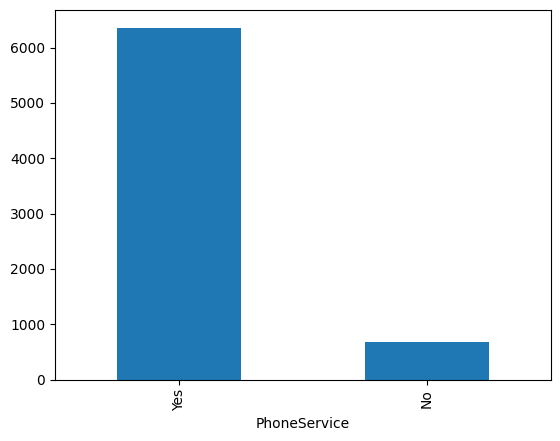

In [30]:
df['PhoneService'].value_counts().plot(kind='bar')
df['PhoneService'] = df['PhoneService'].map({'No': 0, 'Yes': 1})


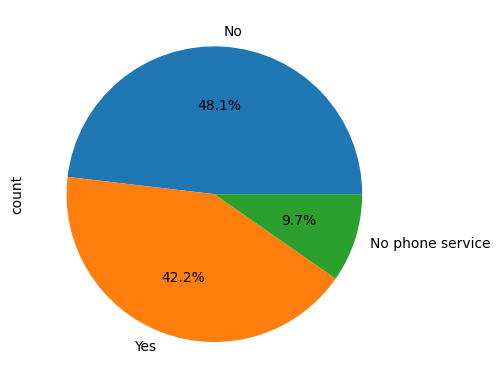

In [31]:
df['MultipleLines'].value_counts().plot(kind='pie',autopct='%.1f%%')
#
mapping_dict = {'No phone service': 0, 'No': 0, 'Yes': 1}

df['MultipleLines'] = df['MultipleLines'].map(mapping_dict)

In [32]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

In [33]:
df.InternetService = le.fit_transform(df.InternetService)

In [36]:
df.Contract = le.fit_transform(df.Contract)

In [35]:
df.PaymentMethod = le.fit_transform(df.PaymentMethod)

In [37]:
df.sample(n=10)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
4615,1,0,1,0,72,1,1,0,Yes,Yes,No,Yes,No,No,2,No,0,64.75,4804.75,No
4929,0,1,1,0,63,1,0,0,Yes,Yes,Yes,Yes,Yes,Yes,1,Yes,0,84.00,5329.55,No
5796,1,0,1,1,47,0,0,0,Yes,Yes,Yes,No,Yes,Yes,2,Yes,1,60.00,2768.65,No
5490,0,0,0,0,6,1,0,0,Yes,Yes,No,No,No,No,0,Yes,0,55.70,335.65,No
642,0,0,0,0,1,1,0,1,No,No,No,No,Yes,Yes,0,Yes,2,89.55,89.55,Yes
2212,0,0,0,0,10,1,0,2,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,1,No,3,19.50,225.85,No
4390,0,0,1,1,22,1,0,0,Yes,Yes,No,Yes,No,No,0,Yes,3,57.95,1271.8,No
5029,1,0,1,0,7,1,0,0,Yes,No,No,No,No,No,0,Yes,0,50.30,355.1,No
1707,1,1,0,0,3,1,0,1,No,No,Yes,No,No,No,0,No,2,73.85,196.4,No
4307,1,1,0,0,37,1,1,1,No,No,No,No,Yes,Yes,0,Yes,2,96.55,3580.3,Yes


In [38]:
df.replace('No internet service','No',inplace=True)
df.replace('No phone service','No',inplace=True)

In [39]:
yes_no_columns = ['Partner','Dependents','PhoneService','MultipleLines','OnlineSecurity','OnlineBackup',
                  'DeviceProtection','TechSupport','StreamingTV','StreamingMovies','PaperlessBilling','Churn']
for col in yes_no_columns:
    df[col].replace({'Yes': 1,'No': 0},inplace=True)

/tmp/ipykernel_182/2444924067.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].replace({'Yes': 1,'No': 0},inplace=True)
/tmp/ipykernel_182/2444924067.py:4: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[col].replace({'Yes': 1,'No': 0},inplace=True)


In [40]:
pd.to_numeric(df.TotalCharges,errors='coerce').isnull().sum()

np.int64(11)

In [41]:
df[pd.to_numeric(df.TotalCharges,errors='coerce').isnull()]

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,1,0,1,1,0,0,0,0,1,0,1,1,1,0,2,1,0,52.55,,0
753,0,0,0,1,0,1,0,2,0,0,0,0,0,0,2,0,3,20.25,,0
936,1,0,1,1,0,1,0,0,1,1,1,0,1,1,2,0,3,80.85,,0
1082,0,0,1,1,0,1,1,2,0,0,0,0,0,0,2,0,3,25.75,,0
1340,1,0,1,1,0,0,0,0,1,1,1,1,1,0,2,0,1,56.05,,0
3331,0,0,1,1,0,1,0,2,0,0,0,0,0,0,2,0,3,19.85,,0
3826,0,0,1,1,0,1,1,2,0,0,0,0,0,0,2,0,3,25.35,,0
4380,1,0,1,1,0,1,0,2,0,0,0,0,0,0,2,0,3,20.00,,0
5218,0,0,1,1,0,1,0,2,0,0,0,0,0,0,1,1,3,19.70,,0
6670,1,0,1,1,0,1,1,0,0,1,1,1,1,0,2,0,3,73.35,,0


In [42]:
df = df[df.TotalCharges!=' ']
df.shape

(7032, 20)

In [43]:
cols_to_scale = ['tenure','MonthlyCharges','TotalCharges']

from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
df[cols_to_scale] = scaler.fit_transform(df[cols_to_scale])

/tmp/ipykernel_182/2641640000.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[cols_to_scale] = scaler.fit_transform(df[cols_to_scale])


In [44]:
df[cols_to_scale ].sample(5)

,tenure,MonthlyCharges,TotalCharges
2931,0.450704,0.866667,0.397675
5229,0.591549,0.888557,0.521013
6582,0.985915,0.880597,0.838270
5416,0.788732,0.763682,0.636626
2173,0.042254,0.674627,0.033383


In [45]:
def summary(df):
    summary_df = pd.DataFrame(df.dtypes, columns=['dtypes'])
    summary_df['missing#'] = df.isna().sum()
    summary_df['missing%'] = (df.isna().sum())/len(df)
    summary_df['unique'] = df.nunique().values
    summary_df['count'] = df.count().values
    return summary_df

summary(df).style.background_gradient(cmap='Blues')

,dtypes,missing#,missing%,unique,count
gender,int64,0,0.000000,2,7032
SeniorCitizen,int64,0,0.000000,2,7032
Partner,int64,0,0.000000,2,7032
Dependents,int64,0,0.000000,2,7032
tenure,float64,0,0.000000,72,7032
PhoneService,int64,0,0.000000,2,7032
MultipleLines,int64,0,0.000000,2,7032
InternetService,int64,0,0.000000,3,7032
OnlineSecurity,int64,0,0.000000,2,7032
OnlineBackup,int64,0,0.000000,2,7032


In [46]:
X = df.drop('Churn',axis='columns')
y = df['Churn']

In [47]:
X.sample(3)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
5027,0,1,1,0,0.126761,1,1,1,0,0,0,0,0,1,0,0,2,0.669652,0.096117
1389,1,1,1,0,0.464789,1,1,1,0,1,1,0,0,1,0,1,2,0.756219,0.369115
659,0,0,1,0,0.507042,1,0,2,0,0,0,0,0,0,0,0,0,0.020896,0.078335


In [48]:
y.sample(3)

,Churn
5423,1
4538,1
6502,0


In [49]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=5)

In [50]:
X_train.shape

(5625, 19)

In [51]:
X_test.shape

(1407, 19)

<Axes: >

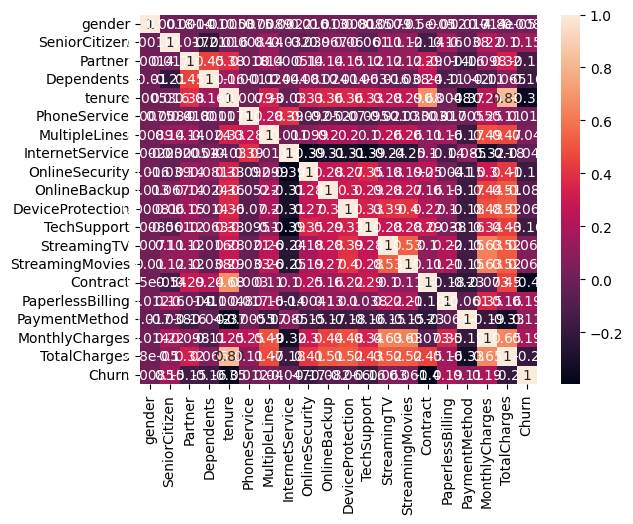

In [52]:
from numpy._core import numeric
sns.heatmap(df.corr(),annot=True)

In [55]:
model = LogisticRegression()
model.fit(X_train,y_train)

LogisticRegression()

In [56]:
pred = model.predict(X_test)

In [57]:
prob = model.predict_proba(X_test)

In [58]:
probabilities = model.predict_proba(X_test)[:, 1]
sorted_idx = np.argsort(X_test['tenure'].values)
x_values = X_test['tenure'].values[sorted_idx]
y_values = probabilities[sorted_idx]

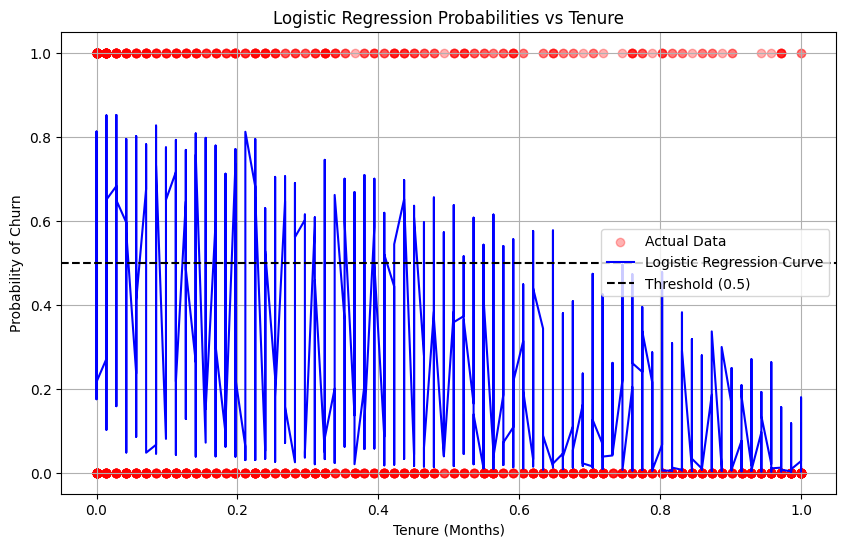

In [59]:
# Sigmoid Function graph
plt.figure(figsize=(10, 6))
plt.scatter(X_test['tenure'], y_test, color='red', alpha=0.3, label='Actual Data')
plt.plot(x_values, y_values, color='blue', label='Logistic Regression Curve')
plt.axhline(0.5, color='black', linestyle='--', label='Threshold (0.5)')
plt.xlabel('Tenure (Months)')
plt.ylabel('Probability of Churn')
plt.title('Logistic Regression Probabilities vs Tenure')
plt.legend()
plt.grid(True)
plt.show()

In [60]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, pred)

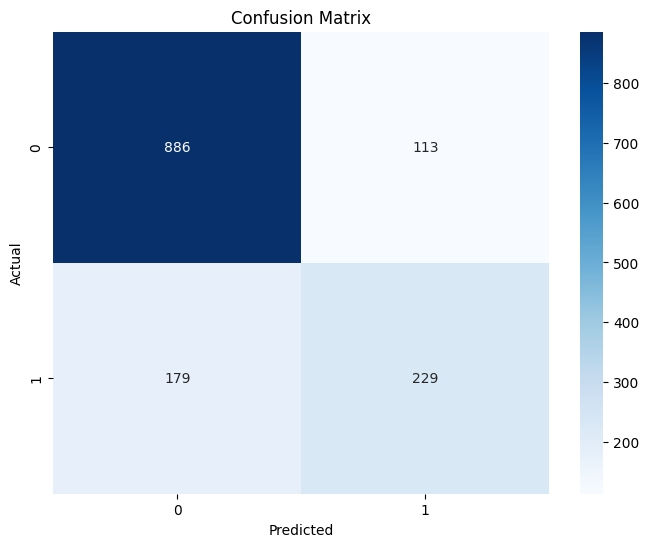

In [62]:
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()